In [ ]:
from datascience import *
import numpy as np
path_data = 'data/'
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


# 표본 평균의 변동성 (Variability)
중심극한정리(Central Limit Theorem)에 따르면, 큰 무작위 표본 평균의 확률 분포는 대략 정규 분포를 따릅니다. 이 종형 곡선은 모평균(population mean)을 중심으로 합니다. 일부 표본 평균은 더 높고, 일부는 더 낮지만, 모평균으로부터의 편차는 우리가 반복해서 보아왔듯이 양쪽에서 대략 대칭을 이룹니다. 공식적으로 확률론은 표본 평균이 모평균의 *불편(unbiased)* 추정량임을 보여줍니다.

시뮬레이션에서 우리는 또한 더 큰 표본의 평균이 더 작은 표본의 평균보다 모평균 주위에 더 촘촘하게 모여 있는 경향이 있음을 확인했습니다. 이 섹션에서는 표본 평균의 변동성을 정량화하고 변동성과 표본 크기 간의 관계를 발전시켜 보겠습니다.

항공편 지연 테이블부터 시작하겠습니다. 평균 지연 시간은 약 16.7분이며, 지연 분포는 오른쪽으로 치우쳐 있습니다.

In [ ]:
united = Table.read_table(path_data + 'united_summer2015.csv')
delay = united.select('Delay')

In [ ]:
united

Date,Flight Number,Destination,Delay
6/1/15,73,HNL,257
6/1/15,217,EWR,28
6/1/15,237,STL,-3
6/1/15,250,SAN,0
6/1/15,267,PHL,64
6/1/15,273,SEA,-6
6/1/15,278,SEA,-8
6/1/15,292,EWR,12
6/1/15,300,HNL,20
6/1/15,317,IND,-10


In [ ]:
pop_mean = np.mean(delay.column('Delay'))
pop_mean

16.658155515370705

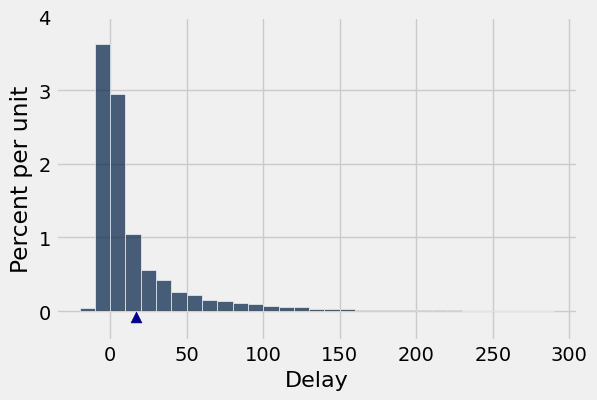

In [ ]:
delay.hist(bins=np.arange(-20, 300, 10))
plots.scatter(pop_mean, -0.0008, marker='^', color='darkblue', s=60)
plots.ylim(-0.004, 0.04);

이제 무작위 표본을 추출하여 표본 평균의 확률 분포를 살펴보겠습니다. 여느 때와 마찬가지로 시뮬레이션을 사용하여 이 분포에 대한 경험적 근사치를 얻을 것입니다.

나중에 표본 크기를 변경할 것이기 때문에 이를 수행하기 위해 `simulate_sample_mean` 함수를 정의하겠습니다. 인수는 테이블 이름, 변수가 포함된 열의 레이블, 표본 크기 및 시뮬레이션 횟수입니다.

In [ ]:
"""Empirical distribution of random sample means"""

def simulate_sample_mean(table, label, sample_size, repetitions):

    means = make_array()

    for i in range(repetitions):
        new_sample = table.sample(sample_size)
        new_sample_mean = np.mean(new_sample.column(label))
        means = np.append(means, new_sample_mean)

    sample_means = Table().with_column('Sample Means', means)

    # Display empirical histogram and print all relevant quantities
    sample_means.hist(bins=20)
    plots.xlabel('Sample Means')
    plots.title('Sample Size ' + str(sample_size))
    print("Sample size: ", sample_size)
    print("Population mean:", np.mean(table.column(label)))
    print("Average of sample means: ", np.mean(means))
    print("Population SD:", np.std(table.column(label)))
    print("SD of sample means:", np.std(means))

지연 건수 100개의 무작위 표본 평균, 그 다음 400개, 마지막으로 625개의 평균을 시뮬레이션해 봅시다. 각 과정을 10,000번 반복할 것입니다. `xlim`과 `ylim` 라인은 비교하기 쉽도록 모든 플롯에서 축을 일관되게 설정합니다. 각 셀에서 이 두 줄의 코드는 무시해도 됩니다.

Sample size:  100
Population mean: 16.6581555154
Average of sample means:  16.6554
Population SD: 39.4801998516
SD of sample means: 3.92419114468


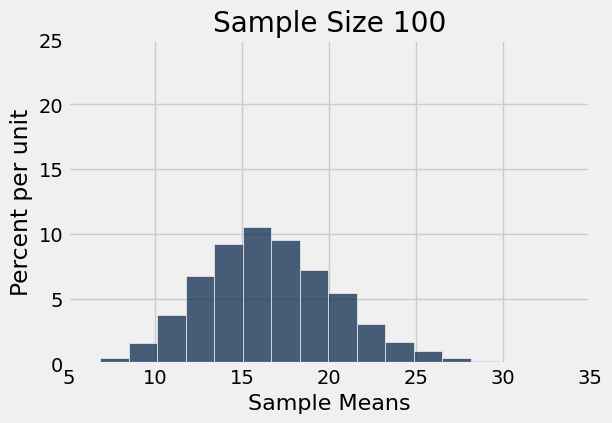

In [ ]:
simulate_sample_mean(delay, 'Delay', 100, 10000)
plots.xlim(5, 35)
plots.ylim(0, 0.25);

Sample size:  400
Population mean: 16.6581555154
Average of sample means:  16.665868
Population SD: 39.4801998516
SD of sample means: 1.97333734548


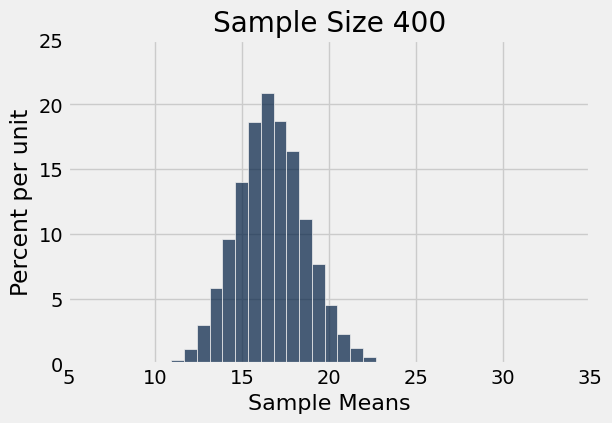

In [ ]:
simulate_sample_mean(delay, 'Delay', 400, 10000)
plots.xlim(5, 35)
plots.ylim(0, 0.25);

Sample size:  625
Population mean: 16.6581555154
Average of sample means:  16.66471616
Population SD: 39.4801998516
SD of sample means: 1.58450099847


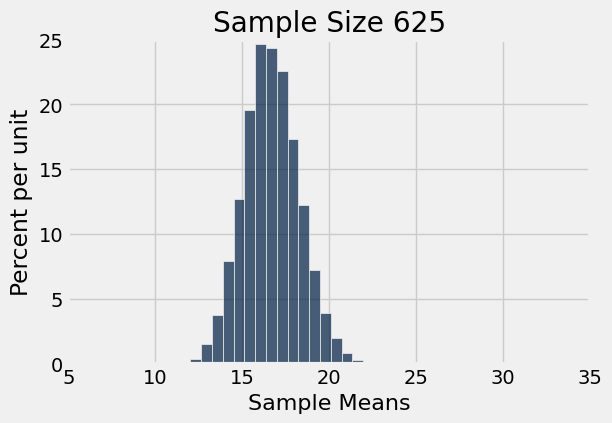

In [ ]:
simulate_sample_mean(delay, 'Delay', 625, 10000)
plots.xlim(5, 35)
plots.ylim(0, 0.25);

중심극한정리가 작동하는 것을 볼 수 있습니다 – 지연 자체의 히스토그램은 정규 분포와 거리가 멀지만 표본 평균의 히스토그램은 대략 정규 분포를 따릅니다.

또한 표본 평균의 세 히스토그램 각각이 모평균에 매우 가깝게 중심을 두고 있음을 볼 수 있습니다. 각 경우에 "표본 평균의 평균"은 모평균인 16.66분에 매우 가깝습니다. 두 값 모두 각 히스토그램 위의 출력물에 제공됩니다. 예상대로 표본 평균은 모평균의 불편 추정량입니다.

## 모든 표본 평균의 표준 편차(SD)

또한 표본 크기가 커짐에 따라 히스토그램이 좁아지고 그에 따라 더 높아지는 것을 볼 수 있습니다. 이전에도 본 적이 있지만, 이제는 퍼짐(spread)의 척도에 더 주의를 기울일 것입니다.

모든 지연 모집단의 표준 편차는 약 40분입니다.

In [ ]:
pop_sd = np.std(delay.column('Delay'))
pop_sd

39.480199851609314

위의 표본 평균 히스토그램에서 표준 편차(SD)를 살펴보십시오. 세 가지 모두에서 지연 모집단의 표준 편차는 약 40분인데, 이는 모든 표본이 동일한 모집단에서 추출되었기 때문입니다.

이제 표본 크기가 100일 때 모든 10,000개 표본 평균의 표준 편차를 보십시오. 그 표준 편차는 모표준 편차의 약 10분의 1입니다. 표본 크기가 400일 때 모든 표본 평균의 표준 편차는 모표준 편차의 약 20분의 1입니다. 표본 크기가 625일 때 표본 평균의 표준 편차는 모표준 편차의 약 25분의 1입니다.

표본 평균의 경험적 분포의 표준 편차를 "모표준 편차를 표본 크기의 제곱근으로 나눈 값"과 비교하는 것이 좋은 생각인 것 같습니다.

다음은 수치 값입니다. 첫 번째 열의 각 표본 크기에 대해 해당 크기의 무작위 표본 10,000개를 추출하고 10,000개의 표본 평균을 계산했습니다. 두 번째 열에는 10,000개 표본 평균의 표준 편차가 포함됩니다. 세 번째 열에는 "모표준 편차를 표본 크기의 제곱근으로 나눈 값"의 계산 결과가 포함됩니다.

이 셀은 대규모 시뮬레이션이므로 실행하는 데 시간이 좀 걸립니다. 하지만 곧 기다릴 가치가 있다는 것을 알게 될 것입니다.

In [ ]:
repetitions = 10000
sample_sizes = np.arange(25, 626, 25)

sd_means = make_array()

for n in sample_sizes:
    means = make_array()
    for i in np.arange(repetitions):
        means = np.append(means, np.mean(delay.sample(n).column('Delay')))
    sd_means = np.append(sd_means, np.std(means))

sd_comparison = Table().with_columns(
    'Sample Size n', sample_sizes,
    'SD of 10,000 Sample Means', sd_means,
    'pop_sd/sqrt(n)', pop_sd/np.sqrt(sample_sizes)
)

In [ ]:
sd_comparison

Sample Size n,"SD of 10,000 Sample Means",pop_sd/sqrt(n)
25,7.89655,7.89604
50,5.50198,5.58334
75,4.54748,4.55878
100,3.95639,3.94802
125,3.52479,3.53122
150,3.24435,3.22354
175,2.99736,2.98442
200,2.79744,2.79167
225,2.6526,2.63201
250,2.49807,2.49695


두 번째 열과 세 번째 열의 값은 매우 가깝습니다. 표본 크기를 가로축으로 하여 각 열을 그래프로 그리면 두 그래프는 본질적으로 구별할 수 없습니다.

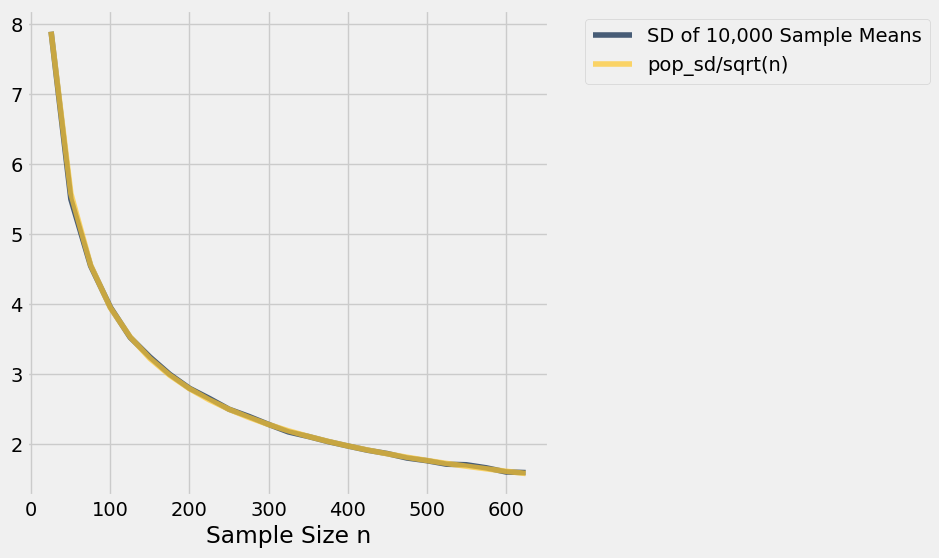

In [ ]:
sd_comparison.plot('Sample Size n')

실제로는 두 개의 곡선이 있습니다. 하지만 서로 너무 가까워서 마치 하나만 있는 것처럼 보입니다.

우리가 보고 있는 것은 일반적인 결과의 한 사례입니다. 위의 그래프는 각 표본 크기에 대해 10,000번 반복한 것을 기반으로 한다는 점을 기억하십시오. 그러나 각 크기의 표본은 10,000개보다 훨씬 많습니다. 표본 평균의 확률 분포는 고정된 크기의 *모든 가능한 표본*의 평균을 기반으로 합니다.

**표본 크기를 고정하십시오.** 표본이 모집단에서 복원 추출로 무작위로 추출되는 경우, 다음이 성립합니다.

$$
{\text{SD of all possible sample means}} ~=~
\frac{\text{Population SD}}{\sqrt{\text{sample size}}}
$$

이것은 추출할 수 있는 모든 가능한 표본의 평균에 대한 표준 편차입니다. **이는 표본 평균이 모평균에서 대략 얼마나 떨어져 있는지를 측정합니다.**

## 표본 평균에 대한 중심극한정리
모집단에서 복원 추출로 큰 무작위 표본을 추출하면, 모집단의 분포와 관계없이 표본 평균의 확률 분포는 대략 정규 분포를 따르며, 모평균을 중심으로 하고, 표준 편차는 모표준 편차를 표본 크기의 제곱근으로 나눈 값과 같습니다.

## 표본 평균의 정확도
모든 가능한 표본 평균의 표준 편차는 표본 평균이 얼마나 변동할 수 있는지를 측정합니다. 따라서 이는 모평균의 추정치로서 표본 평균의 정확도를 나타내는 척도로 간주됩니다. 표준 편차가 작을수록 추정치는 더 정확합니다.

공식은 다음을 보여줍니다:
- 모집단 크기는 표본 평균의 정확도에 영향을 미치지 않습니다. 모집단 크기는 공식 어디에도 나타나지 않습니다.
- 모표준 편차는 상수입니다; 모집단에서 추출된 모든 표본에 대해 동일합니다. 표본 크기는 변경될 수 있습니다. 표본 크기가 분모에 나타나기 때문에 표본 크기가 커질수록 표본 평균의 변동성은 *감소*하고 따라서 정확도는 증가합니다.

## 제곱근 법칙 (The Square Root Law)
표준 편차 비교 테이블에서 항공편 지연 25개에 대한 무작위 표본 평균의 표준 편차는 약 8분임을 알 수 있습니다. 표본 크기에 4를 곱하면 크기 100인 표본을 얻게 됩니다. 그 모든 표본 평균의 표준 편차는 약 4분입니다. 이는 8분보다 작지만 4배 더 작은 것은 아닙니다; 단지 2배 더 작을 뿐입니다. 이는 분모의 표본 크기에 제곱근이 씌워져 있기 때문입니다. 표본 크기는 4배 증가했지만 표준 편차는 $2 = \sqrt{4}$배 감소했습니다. 다시 말해, 정확도가 $2 = \sqrt{4}$배 증가했습니다.

일반적으로 표본 크기에 어떤 팩터를 곱하면 표본 평균의 정확도는 그 팩터의 제곱근만큼 올라갑니다.

따라서 정확도를 10배 높이려면 표본 크기에 100을 곱해야 합니다. 정확도를 얻는 것은 쉽지 않습니다!